Notebook 01 is solely focused on a very crude MFVI implementation. Notebook 02 will implement a better working version of mean field VI, integrate flipout and compare to HMC Posterior. Notebook 03 will do a very quick and dirty OED, where batches of points are selected using BoTorch on EIG objective, to compare results on oracle data BNN and BNN built sequentially via randomly selected / sliced space-filling designs.

Only from notebook 04, we will flip a switch and fit an NN with the residual being modeled by Gaussian Processes instead. It is possible we may do notebook 01 and notebook 04 first too, depending on how hard the implementation is. Later notebooks will also implement SVGD.

Needed:

- KL divergence expressions for different log priors
- DNN to BNN flag

Later notebooks will focus on the utility of hierarchical information processing, and potential ways to explore nestedness of $h$, where $h$ is one or more QoIs derived from the forward model.

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.distributions as distributions
from torch.utils.data import Dataset, DataLoader
from itertools import repeat
import collections
from scipy.special import logsumexp
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math
from tqdm import tqdm, trange

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/ajivani/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [59]:
def write_weight_histograms(epoch):
    writer.add_histogram('histogram/w1_mu', net.l1.weight_mu,epoch)
    writer.add_histogram('histogram/w1_rho', net.l1.weight_rho,epoch)
    writer.add_histogram('histogram/w2_mu', net.l2.weight_mu,epoch)
    writer.add_histogram('histogram/w2_rho', net.l2.weight_rho,epoch)
    writer.add_histogram('histogram/w3_mu', net.l3.weight_mu,epoch)
    writer.add_histogram('histogram/w3_rho', net.l3.weight_rho,epoch)
    writer.add_histogram('histogram/b1_mu', net.l1.bias_mu,epoch)
    writer.add_histogram('histogram/b1_rho', net.l1.bias_rho,epoch)
    writer.add_histogram('histogram/b2_mu', net.l2.bias_mu,epoch)
    writer.add_histogram('histogram/b2_rho', net.l2.bias_rho,epoch)
    writer.add_histogram('histogram/b3_mu', net.l3.bias_mu,epoch)
    writer.add_histogram('histogram/b3_rho', net.l3.bias_rho,epoch)

In [ ]:
from tensorboardX import SummaryWriter

In [48]:
writer = SummaryWriter()

In [3]:
plt.rc("axes.spines", right=True, top=True)
plt.rc("figure",
       dpi=300,
      #  figsize=(9, 3)
      )
plt.rc("font", family="serif")
plt.rc("legend", edgecolor="none", frameon=True)
plt.style.use("dark_background")

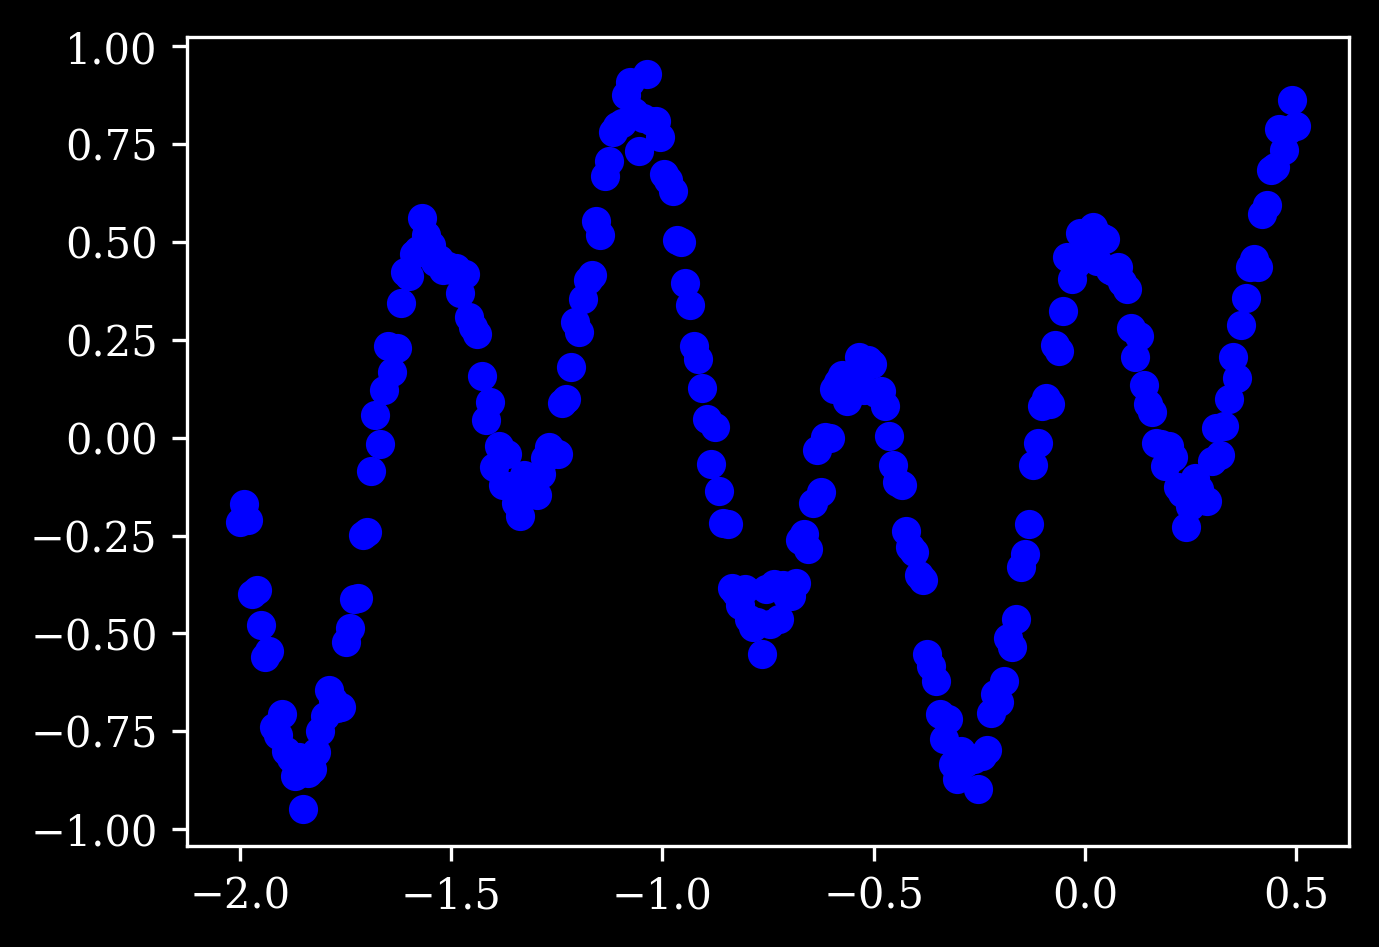

In [14]:
var_n = 0.05 ** 2
f = lambda x, noisy: 0.4*np.sin(4 * x)+0.5*np.cos(12 * x)+noisy*np.sqrt(var_n)*np.random.normal(size=x.shape)

x_or = np.linspace(-2, 0.5, 250)
y_or = f(x_or, True)
fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1)
ax.plot(x_or, y_or, color='blue', linestyle='none', marker='o', markersize=6, label='noisy training data Oracle')

`x_or` and `y_or` denote the training set used for one-shot training of BNN

In [21]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(x_or, y_or, train_size=0.7, shuffle=True)
scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, 1))
X_train = scaler.transform(X_train_raw.reshape(-1, 1))
X_test = scaler.transform(X_test_raw.reshape(-1, 1))

# scalerY = PowerTransformer()
# scalerY.fit(y_train_raw.reshape(-1, 1))
# y_train = scalerY.transform(y_train_raw.reshape(-1, 1))
# y_test = scalerY.transform(y_test_raw.reshape(-1, 1))


X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.float32).reshape(-1, 1)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [118]:
class Gaussian(object):
    def __init__(self, mu, rho):
        super().__init__()
        self.mu = mu
        self.rho = rho
        self.normal = torch.distributions.Normal(0,1)
    
    @property
    def sigma(self):
        return torch.log1p(torch.exp(self.rho))
    
    def sample(self):
        epsilon = self.normal.sample(self.rho.size()).to(device)
        return self.mu + self.sigma * epsilon
    
    def log_prob(self, input):
        return (-math.log(math.sqrt(2 * math.pi))
                - torch.log(self.sigma)
                - ((input - self.mu) ** 2) / (2 * self.sigma ** 2)).sum()

In [119]:
class ScaleMixtureGaussian(object):
    def __init__(self, pi, sigma1, sigma2):
        super().__init__()
        self.pi = pi
        self.sigma1 = sigma1
        self.sigma2 = sigma2
        self.gaussian1 = torch.distributions.Normal(0,sigma1)
        self.gaussian2 = torch.distributions.Normal(0,sigma2)
    
    def log_prob(self, input):
        prob1 = torch.exp(self.gaussian1.log_prob(input))
        prob2 = torch.exp(self.gaussian2.log_prob(input))
        return (torch.log(self.pi * prob1 + (1-self.pi) * prob2)).sum()

In [120]:
PI = 0.25
SIGMA_1 = torch.FloatTensor([math.exp(-0)]).to(device)
SIGMA_2 = torch.FloatTensor([math.exp(-6)]).to(device)

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        # Weight parameters
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).uniform_(-0.2, 0.2))
        self.weight_rho = nn.Parameter(torch.Tensor(out_features, in_features).uniform_(-5,-4))
        self.weight = Gaussian(self.weight_mu, self.weight_rho)
        # Bias parameters
        self.bias_mu = nn.Parameter(torch.Tensor(out_features).uniform_(-0.2, 0.2))
        self.bias_rho = nn.Parameter(torch.Tensor(out_features).uniform_(-5,-4))
        self.bias = Gaussian(self.bias_mu, self.bias_rho)
        # Prior distributions
        self.weight_prior = ScaleMixtureGaussian(PI, SIGMA_1, SIGMA_2)
        self.bias_prior = ScaleMixtureGaussian(PI, SIGMA_1, SIGMA_2)
        self.log_prior = 0
        self.log_variational_posterior = 0

    def forward(self, input, sample=False, calculate_log_probs=False):
        if self.training or sample:
            weight = self.weight.sample()
            bias = self.bias.sample()
        else:
            weight = self.weight.mu
            bias = self.bias.mu
        if self.training or calculate_log_probs:
            self.log_prior = self.weight_prior.log_prob(weight) + self.bias_prior.log_prob(bias)
            self.log_variational_posterior = self.weight.log_prob(weight) + self.bias.log_prob(bias)
        else:
            self.log_prior, self.log_variational_posterior = 0, 0

        return F.linear(input, weight, bias)

In [134]:
CLASSES = 1

class BayesianNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = BayesianLinear(1, 16)
        self.l2 = BayesianLinear(16, 16)
        self.l3 = BayesianLinear(16, 1)
    
    def forward(self, x, sample=False):
        # x = x.view(-1, 28*28)
        x = F.relu(self.l1(x, sample))
        x = F.relu(self.l2(x, sample))
        x = F.relu(self.l3(x, sample))
        return x
    
    def log_prior(self):
        return self.l1.log_prior \
               + self.l2.log_prior \
               + self.l3.log_prior
    
    def log_variational_posterior(self):
        return self.l1.log_variational_posterior \
               + self.l2.log_variational_posterior \
               + self.l3.log_variational_posterior
    
    def sample_elbo(self, input, target, samples=SAMPLES, batch_size=None):
        outputs = torch.zeros(samples, batch_size, CLASSES).to(device)
        log_priors = torch.zeros(samples).to(device)
        log_variational_posteriors = torch.zeros(samples).to(device)
        for i in range(samples):
            outputs[i] = self(input, sample=True)
            log_priors[i] = self.log_prior()
            log_variational_posteriors[i] = self.log_variational_posterior()
        log_prior = log_priors.mean()
        log_variational_posterior = log_variational_posteriors.mean()
        negative_log_likelihood = nllg(outputs.mean(0), target, torch.ones(target.shape[0]))
        loss = (log_variational_posterior - log_prior)/NUM_BATCHES + negative_log_likelihood
        return loss, log_prior, log_variational_posterior, negative_log_likelihood

net = BayesianNetwork().to(device)

In [135]:
class CustomDataset(Dataset):
    def __init__(self, Xvals, yvals):
        self.Xvals = Xvals
        self.yvals = yvals

    def __len__(self):
        return len(self.yvals)
    
    def __getitem__(self, idx):
        return self.Xvals[idx, :], self.yvals[idx, :]

In [136]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [137]:
len(train_dataset)

175

In [138]:
SAMPLES = 2
BATCH_SIZE = 8
TRAIN_EPOCHS = 20

In [139]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [140]:
for i, (x, y) in enumerate(train_dataloader):
    print(len(x))

8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
8
7


In [141]:
NUM_BATCHES = len(train_dataloader)
NUM_BATCHES

22

In [142]:
def write_loss_scalars(epoch, batch_idx, loss, log_prior, log_variational_posterior, negative_log_likelihood):
    writer.add_scalar('logs/loss', loss, epoch*NUM_BATCHES+batch_idx)
    writer.add_scalar('logs/complexity_cost', log_variational_posterior-log_prior, epoch*NUM_BATCHES+batch_idx)
    writer.add_scalar('logs/log_prior', log_prior, epoch*NUM_BATCHES+batch_idx)
    writer.add_scalar('logs/log_variational_posterior', log_variational_posterior, epoch*NUM_BATCHES+batch_idx)
    writer.add_scalar('logs/negative_log_likelihood', negative_log_likelihood, epoch*NUM_BATCHES+batch_idx)


def write_weight_histograms(epoch):
    writer.add_histogram('histogram/w1_mu', net.l1.weight_mu,epoch)
    writer.add_histogram('histogram/w1_rho', net.l1.weight_rho,epoch)
    writer.add_histogram('histogram/w2_mu', net.l2.weight_mu,epoch)
    writer.add_histogram('histogram/w2_rho', net.l2.weight_rho,epoch)
    writer.add_histogram('histogram/w3_mu', net.l3.weight_mu,epoch)
    writer.add_histogram('histogram/w3_rho', net.l3.weight_rho,epoch)
    writer.add_histogram('histogram/b1_mu', net.l1.bias_mu,epoch)
    writer.add_histogram('histogram/b1_rho', net.l1.bias_rho,epoch)
    writer.add_histogram('histogram/b2_mu', net.l2.bias_mu,epoch)
    writer.add_histogram('histogram/b2_rho', net.l2.bias_rho,epoch)
    writer.add_histogram('histogram/b3_mu', net.l3.bias_mu,epoch)
    writer.add_histogram('histogram/b3_rho', net.l3.bias_rho,epoch)

In [143]:
nllg = nn.GaussianNLLLoss()

In [144]:
def train(net, optimizer, epoch):
    net.train()
    if epoch == 0: # write initial distributions
        write_weight_histograms(epoch)
    for batch_idx, (data, target) in enumerate(tqdm(train_dataloader)):
        data, target = data.to(device), target.to(device)
        net.zero_grad()
        loss, log_prior, log_variational_posterior, negative_log_likelihood = net.sample_elbo(data, target, batch_size=len(data))
        loss.backward()
        optimizer.step()
        write_loss_scalars(epoch, batch_idx, loss, log_prior, log_variational_posterior, negative_log_likelihood)
    write_weight_histograms(epoch+1)

In [145]:
optimizer = optim.Adam(net.parameters())
for epoch in range(TRAIN_EPOCHS):
    train(net, optimizer, epoch)

100%|██████████| 22/22 [00:00<00:00, 102.99it/s]


Visualization

Text(0, 0.5, 'y')

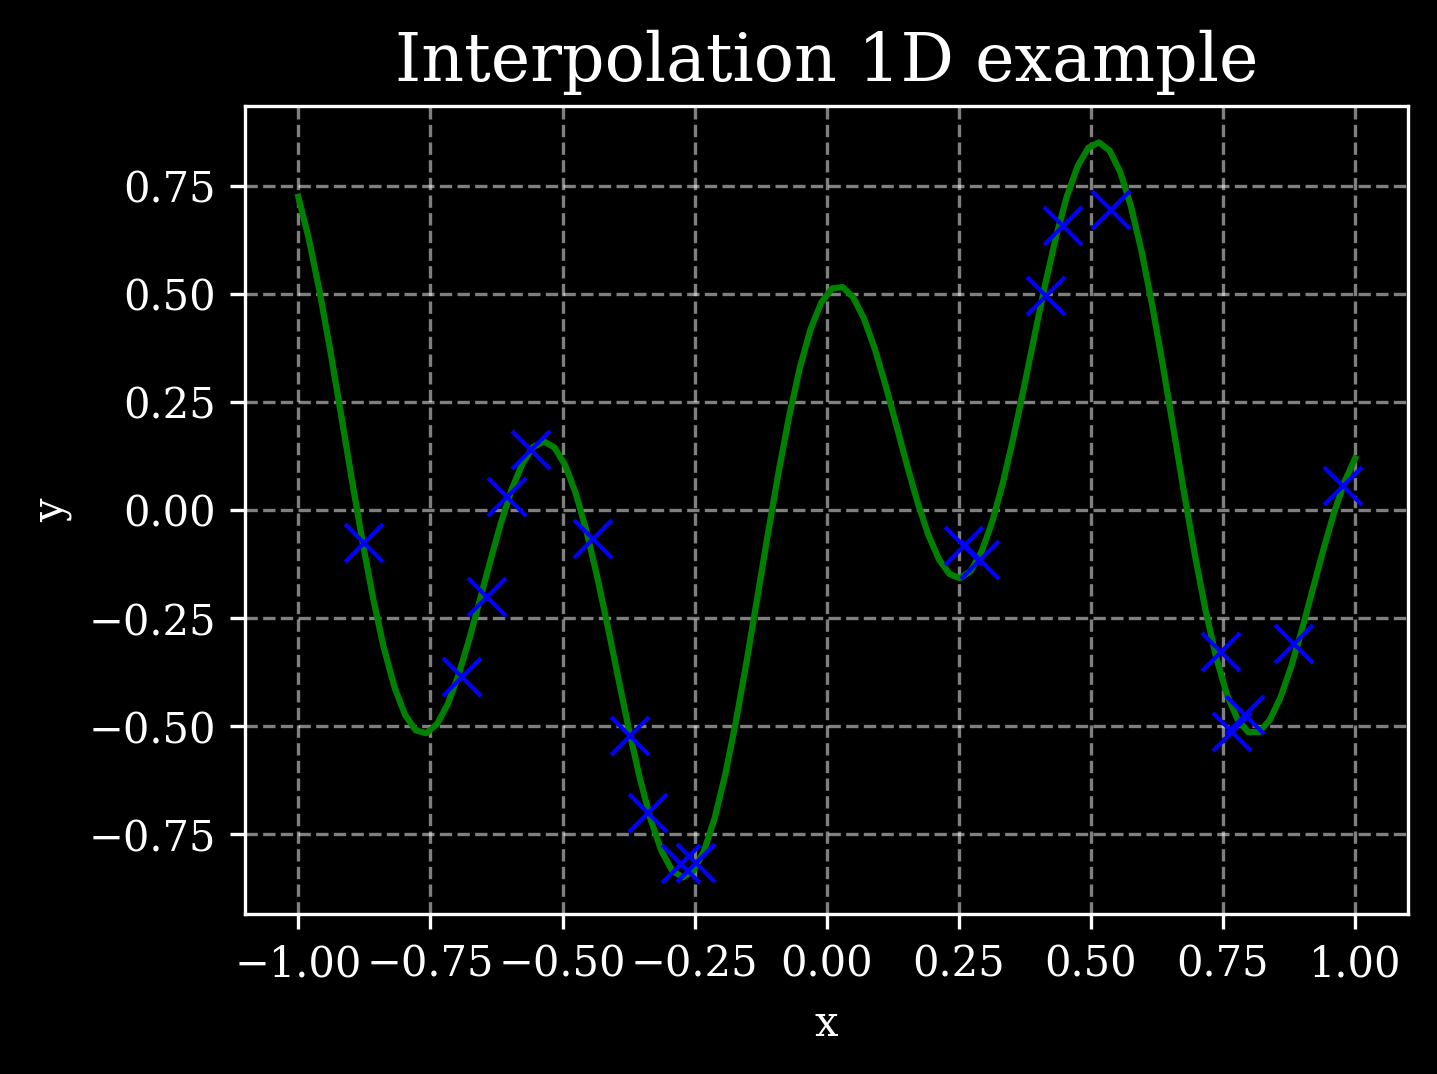

In [ ]:


n_data = 20
xn = 1/5 * np.array([[-1.23374131], [-2.80075168], [-3.44975161], [-3.21186531], [-3.02209586], [-2.21373764], [-4.37775872],
            [-1.86404408], [-1.69559337], [-1.37603453], [ 3.72937   ], [ 4.88684951], [ 2.23649116], [ 2.69073348],
            [ 1.29613003], [ 3.95513359], [ 3.83697005], [ 1.45216711], [ 4.42576355], [ 2.07597818]])
yn = np.array([-0.8181956697783953, 0.13885402687227927, -0.3862388281350327, -0.20234915578844812, 
    0.03000639994622538, -0.06849287803937654, -0.07642553448272046, -0.5232257730716847, 
        -0.7023192220709934, -0.8190169865472378, -0.3285415162946372, 0.05488363929789496, 
            0.6563808735923208, 0.6941414577967285, -0.08382934737250632, -0.47515928440184424, 
                -0.5146741885584126, -0.11555280503711199, -0.31140762228445024, 0.4945424732107972]).reshape((-1, 1))
x_plot = np.linspace(-1., 1., 100).reshape((-1, 1))

fig, ax = plt.subplots(figsize=(5, 3.5), ncols=1)
ax.plot(x_plot, f(x_plot, False), **{'color': 'green', 'linestyle': '-', 'label': 'data generating function'})
ax.plot(xn, yn, color='blue', linestyle='none', marker='x', markersize=9, label='noisy training data')
# set_stuff(ax)
# ax.set_xticks(fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('Interpolation 1D example', fontsize=16)
ax.set_xlabel("x")
ax.set_ylabel("y")
#plt.legend(loc='upper center', bbox_to_anchor=(0.35, 1.05), ncol=2, fancybox=True, shadow=True)
#plt.legend(fontsize=13, loc='lower right')
#plt.savefig('sinusoid_true_f.pdf', bbox_inches='tight')
# plt.show()